# Graph Feature EDA Notebook

Purpose: explore the city-balanced graph-feature dataset before modeling.

Main question:

**Do graph features help explain or predict street-network entropy?**

This notebook is designed for visual checking. It displays plots first and only saves selected figures when you choose to run the save cells.

## 1. Imports

Use this section once at the start.

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Paths

This cell works whether the notebook is run from the `notebooks` folder or from the repo root.

In [30]:
# Candidate project roots.
candidates = [
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "data").exists() and (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find project root. Run this notebook inside the repo or notebooks folder.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_global"
GRAPH_PATH = PROCESSED_DIR / "graph_features_city_balanced.csv"
ENTROPY_PATH = PROCESSED_DIR / "entropy_features.csv"
OUTPUT_DIR = PROCESSED_DIR / "selected_graph_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Graph dataset:", GRAPH_PATH)
print("Entropy dataset:", ENTROPY_PATH)
print("Selected output folder:", OUTPUT_DIR)

Project root: d:\GitHub\Urban-morphology-classification-
Graph dataset: d:\GitHub\Urban-morphology-classification-\data\processed_global\graph_features_city_balanced.csv
Entropy dataset: d:\GitHub\Urban-morphology-classification-\data\processed_global\entropy_features.csv
Selected output folder: d:\GitHub\Urban-morphology-classification-\data\processed_global\selected_graph_eda


## 3. Load the balanced graph dataset

This dataset should contain 3,808 rows:

- 8 cities
- 476 patches per city

In [31]:
graph_df = pd.read_csv(GRAPH_PATH)

print("Rows:", len(graph_df))
print("Columns:", len(graph_df.columns))
graph_df.head()

Rows: 3808
Columns: 20


,patch_id,city,code,lat,lon,n_nodes,n_edges,mean_node_degree,dead_end_ratio,proportion_3way,proportion_4way,intersection_density,mean_edge_length,std_edge_length,cv_edge_length,total_edge_length,network_density,grain_ratio,meshedness,beta_index
0,barcelona_01314,"Barcelona, Spain",barcelona,41.414547,2.210733,266,395,2.9699,0.0639,0.5301,0.2556,1064.0,29.21,29.04,0.9942,11538.51,46.1540,0.101670,0.2467,1.4850
1,barcelona_01413,"Barcelona, Spain",barcelona,41.421304,2.147692,337,503,2.9852,0.0564,0.5460,0.2493,1348.0,28.83,38.79,1.3454,14503.70,58.0148,0.103528,0.2496,1.4926
2,barcelona_01594,"Barcelona, Spain",barcelona,41.430313,2.210733,54,67,2.4815,0.2037,0.4259,0.1667,216.0,49.54,44.84,0.9051,3319.23,13.2769,0.050090,0.1359,1.2407
3,barcelona_01494,"Barcelona, Spain",barcelona,41.425809,2.150694,286,418,2.9231,0.0664,0.5629,0.2203,1144.0,27.64,36.89,1.3349,11552.91,46.2116,0.105761,0.2346,1.4615
4,barcelona_01213,"Barcelona, Spain",barcelona,41.410043,2.147692,322,473,2.9379,0.0807,0.5590,0.2205,1288.0,27.77,40.03,1.4414,13135.36,52.5414,0.105792,0.2379,1.4689


## 4. Check city balance

This confirms that each city has the same number of valid graph-feature patches.

In [32]:
city_counts = graph_df["code"].value_counts().sort_index()
city_counts

code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64

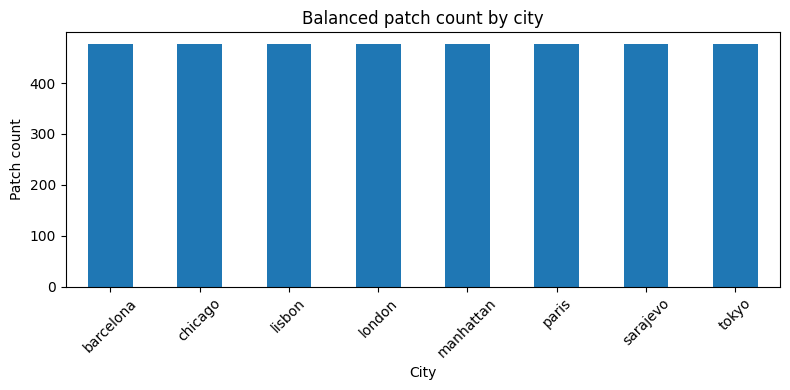

In [33]:
plt.figure(figsize=(8, 4))
city_counts.plot(kind="bar")
plt.title("Balanced patch count by city")
plt.xlabel("City")
plt.ylabel("Patch count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Define graph features and human labels

These labels make the plots easier to read.

In [34]:
graph_features = [
    "dead_end_ratio",
    "proportion_3way",
    "proportion_4way",
    "intersection_density",
    "network_density",
    "meshedness",
    "beta_index",
    "mean_node_degree",
    "mean_edge_length",
    "cv_edge_length",
]

human_labels = {
    "dead_end_ratio": "Dead-end ratio",
    "proportion_3way": "3-way intersection ratio",
    "proportion_4way": "4-way intersection ratio",
    "intersection_density": "Intersection density",
    "network_density": "Street network density",
    "meshedness": "Meshedness",
    "beta_index": "Beta index",
    "mean_node_degree": "Average node degree",
    "mean_edge_length": "Average street segment length",
    "cv_edge_length": "Street segment length variation",
    "entropy_normalized": "Street direction entropy",
    "entropy_normalised": "Street direction entropy",
}

[f for f in graph_features if f not in graph_df.columns]

[]

## 6. Quick statistical summary

Use this to spot very large or very small values before plotting.

In [35]:
graph_df[graph_features].describe().T

,count,mean,std,min,25%,50%,75%,max
dead_end_ratio,3808.0,0.193829,0.090692,0.0000,0.128600,0.18530,0.250000,0.5357
proportion_3way,3808.0,0.482743,0.097276,0.1500,0.421800,0.49550,0.550625,0.7885
proportion_4way,3808.0,0.176757,0.114167,0.0000,0.093200,0.15605,0.239125,0.6418
intersection_density,3808.0,686.387605,381.011984,44.0000,416.000000,648.00000,892.000000,3028.0000
network_density,3808.0,30.444668,12.581730,0.9036,21.957250,30.60190,38.744900,87.4430
meshedness,3808.0,0.164435,0.070356,0.0000,0.121575,0.16290,0.209800,0.3755
beta_index,3808.0,1.312272,0.146307,0.8333,1.228975,1.31300,1.405825,1.7299
mean_node_degree,3808.0,2.624544,0.292614,1.6667,2.457950,2.62610,2.811650,3.4599
mean_edge_length,3808.0,38.337004,13.698792,13.3800,30.190000,35.20500,41.612500,160.6400
cv_edge_length,3808.0,1.047617,0.209202,0.4294,0.907450,1.04840,1.183200,2.1379


## 7. Histogram viewer

Change `feature` to inspect one graph feature at a time.

Histograms answer:

- Does the feature have variation?
- Is it mostly zero?
- Are there extreme values?
- Does it look usable for modeling?

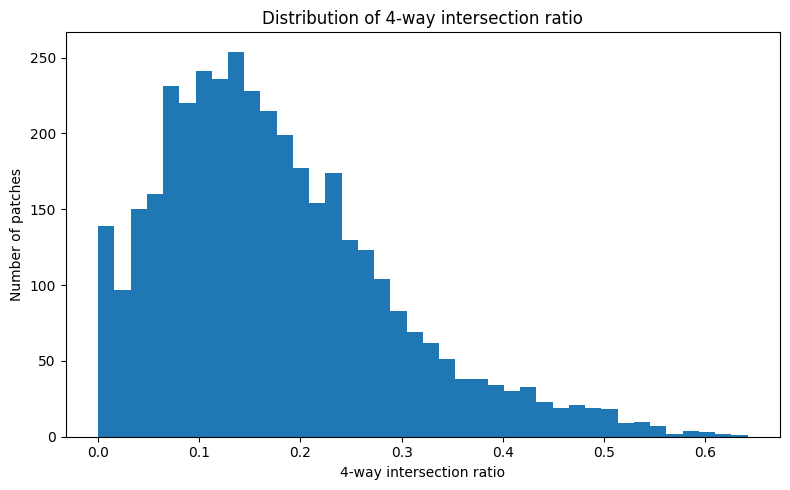

In [36]:
feature = "proportion_4way"

plt.figure(figsize=(8, 5))
plt.hist(graph_df[feature].dropna(), bins=40)
plt.title(f"Distribution of {human_labels.get(feature, feature)}")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()

## 8. All graph histograms in the notebook

This displays all histograms one by one. It does not save files.

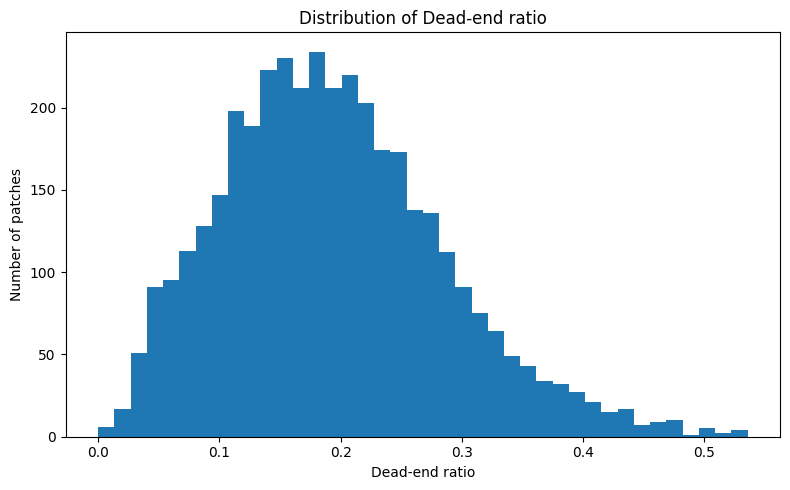

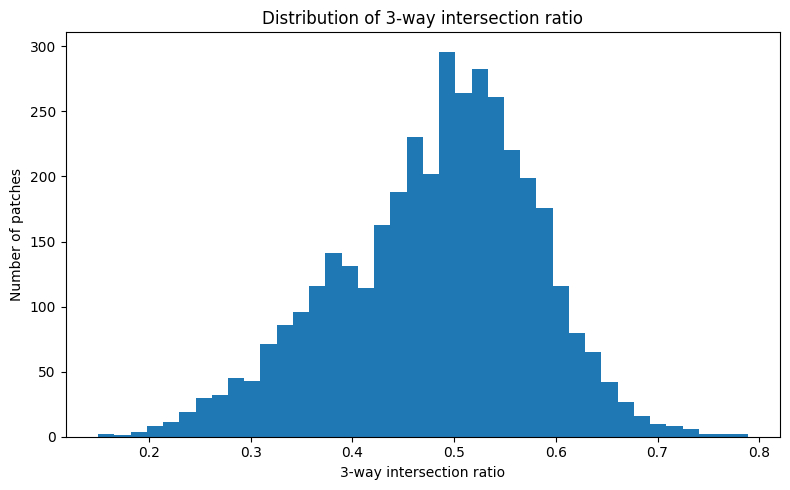

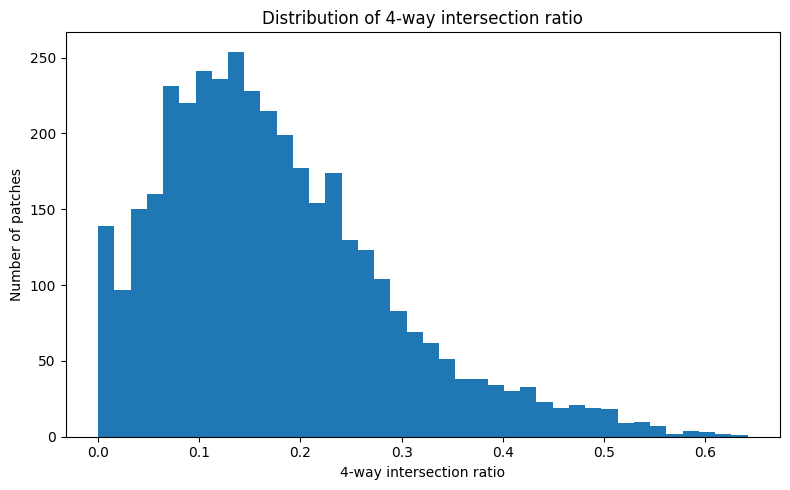

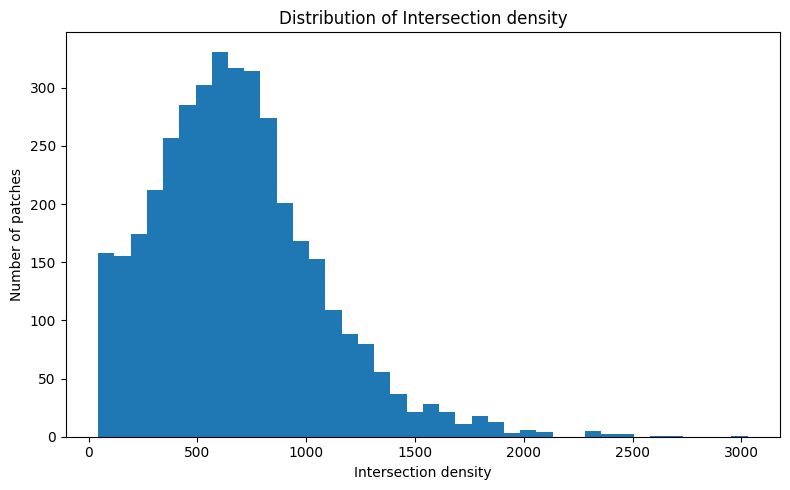

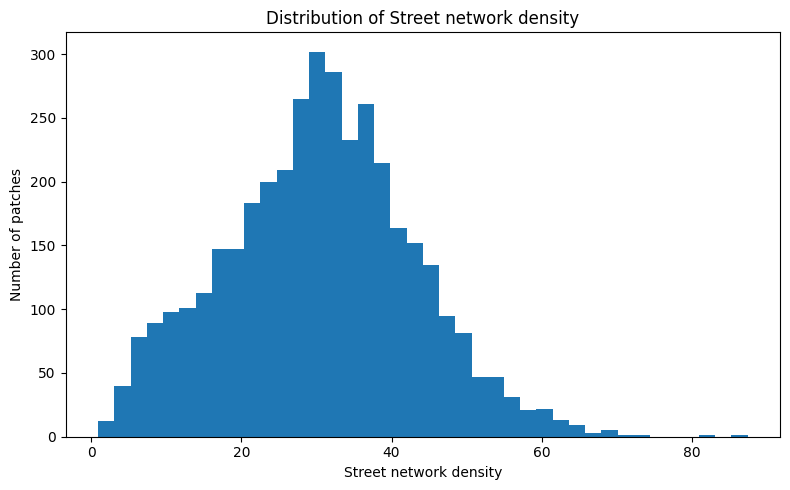

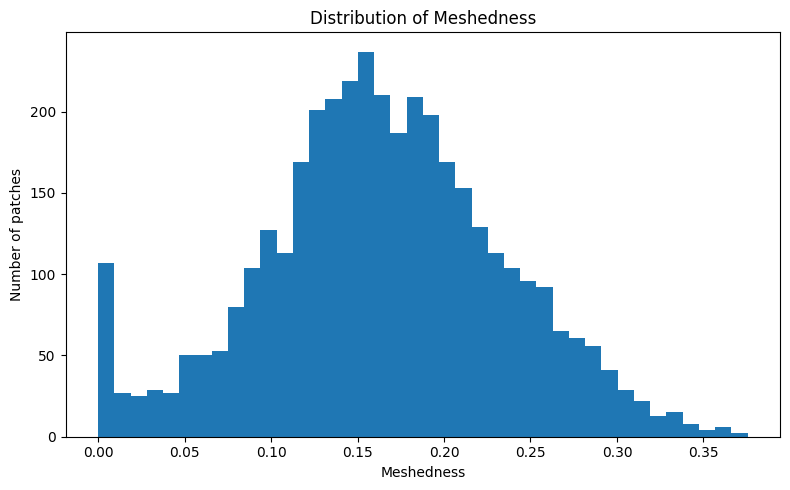

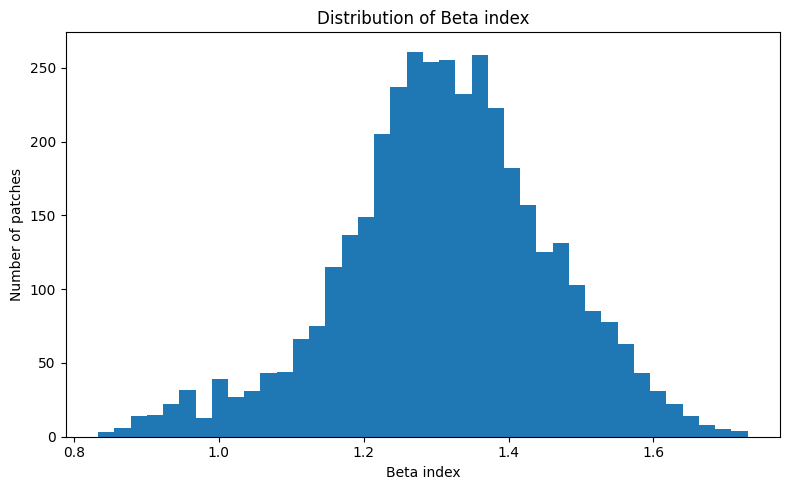

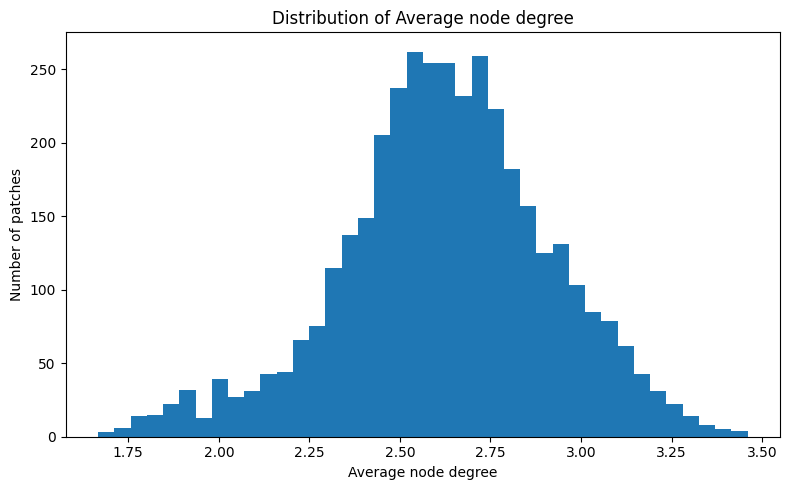

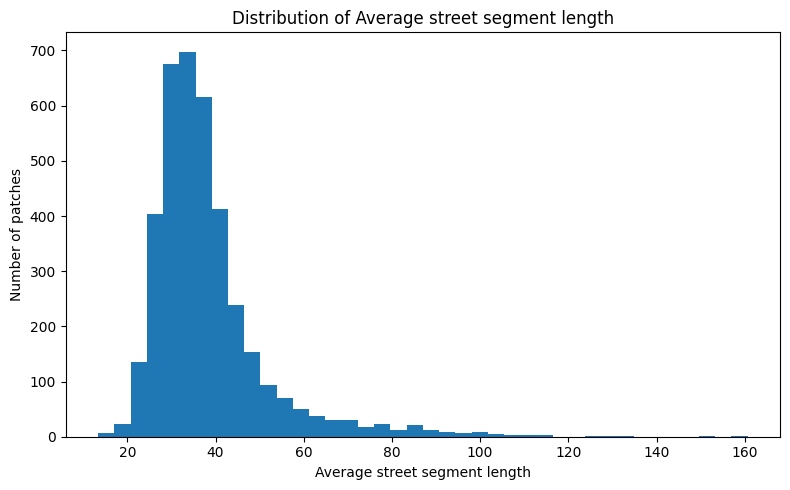

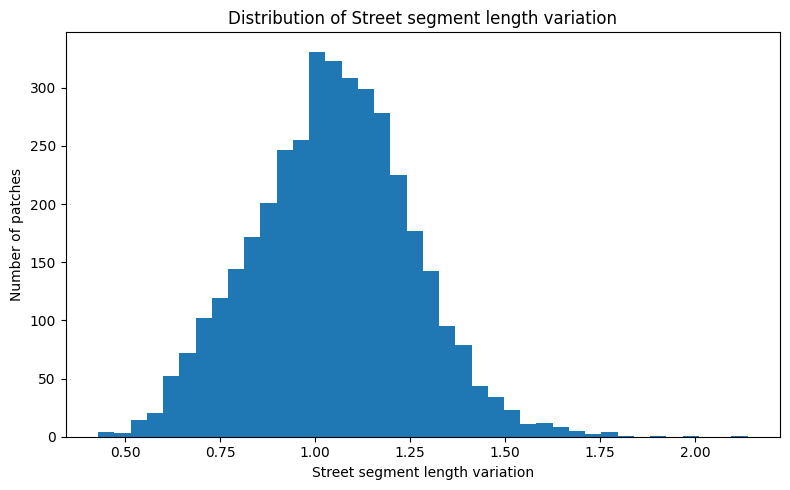

In [37]:
for feature in graph_features:
    plt.figure(figsize=(8, 5))
    plt.hist(graph_df[feature].dropna(), bins=40)
    plt.title(f"Distribution of {human_labels.get(feature, feature)}")
    plt.xlabel(human_labels.get(feature, feature))
    plt.ylabel("Number of patches")
    plt.tight_layout()
    plt.show()

## 9. Boxplots by city

Boxplots show whether each city has a different graph-feature profile.

Change `feature` to inspect different features.

<Figure size 1000x500 with 0 Axes>

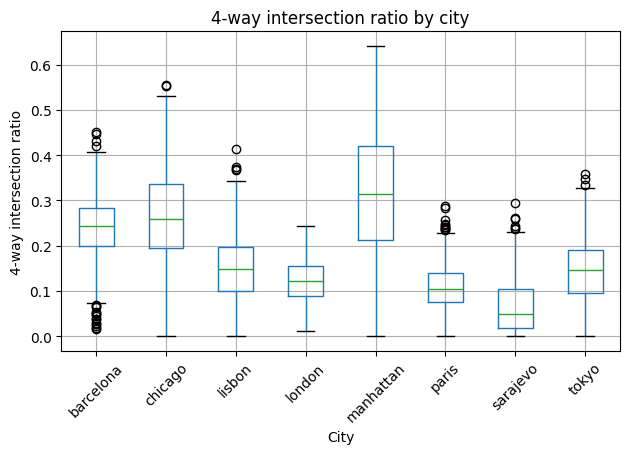

In [38]:
feature = "proportion_4way"

plt.figure(figsize=(10, 5))
graph_df.boxplot(column=feature, by="code", rot=45)
plt.title(f"{human_labels.get(feature, feature)} by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel(human_labels.get(feature, feature))
plt.tight_layout()
plt.show()

## 10. Load and merge entropy data

The graph dataset may not contain entropy yet.

This section tries to merge graph features with `entropy_features.csv` using `patch_id`.

In [39]:
print("Does graph_df already contain entropy?")
print([c for c in graph_df.columns if "entropy" in c.lower()])

if ENTROPY_PATH.exists():
    entropy_df = pd.read_csv(ENTROPY_PATH)
    print("Entropy rows:", len(entropy_df))
    print("Entropy columns:", list(entropy_df.columns))
    display(entropy_df.head())
else:
    print("Entropy file not found:", ENTROPY_PATH)

Does graph_df already contain entropy?
[]
Entropy rows: 8440
Entropy columns: ['patch_id', 'city', 'code', 'lat', 'lon', 'entropy_raw', 'entropy_normalised', 'dominant_bearing', 'n_dominant_peaks']


,patch_id,city,code,lat,lon,entropy_raw,entropy_normalised,dominant_bearing,n_dominant_peaks
0,barcelona_00000,"Barcelona, Spain",barcelona,41.342475,2.108666,2.450286,0.683765,135.0,7
1,barcelona_00001,"Barcelona, Spain",barcelona,41.342475,2.111668,2.498039,0.697091,40.0,6
2,barcelona_00009,"Barcelona, Spain",barcelona,41.342475,2.135684,2.289402,0.638870,110.0,7
3,barcelona_00010,"Barcelona, Spain",barcelona,41.342475,2.138686,2.287146,0.638240,115.0,5
4,barcelona_00011,"Barcelona, Spain",barcelona,41.342475,2.141688,2.551613,0.712041,20.0,5


## 11. Create working EDA dataset

This cell creates `df`.

If entropy is already inside the graph dataset, it uses it directly.

If not, it merges entropy from `entropy_features.csv`.

In [40]:
# Detect entropy column name.
entropy_candidates_graph = [c for c in graph_df.columns if c.lower() in ["entropy_normalized", "entropy_normalised"]]

if entropy_candidates_graph:
    entropy_col = entropy_candidates_graph[0]
    df = graph_df.copy()
    print("Using entropy column already in graph_df:", entropy_col)
else:
    if not ENTROPY_PATH.exists():
        raise FileNotFoundError("No entropy column in graph_df and entropy_features.csv was not found.")
    entropy_df = pd.read_csv(ENTROPY_PATH)
    entropy_candidates = [c for c in entropy_df.columns if c.lower() in ["entropy_normalized", "entropy_normalised"]]
    if not entropy_candidates:
        raise ValueError("Could not find entropy_normalized or entropy_normalised in entropy_features.csv")
    entropy_col = entropy_candidates[0]
    keep_cols = ["patch_id", entropy_col]
    extra_cols = [c for c in ["dominant_bearing", "n_dominant_peaks", "entropy_raw"] if c in entropy_df.columns]
    keep_cols += extra_cols
    df = graph_df.merge(entropy_df[keep_cols], on="patch_id", how="inner")
    print("Merged graph features with entropy column:", entropy_col)

print("Working EDA rows:", len(df))
print("Working EDA columns:", len(df.columns))
print("Entropy column:", entropy_col)
df.head()

Merged graph features with entropy column: entropy_normalised
Working EDA rows: 3808
Working EDA columns: 24
Entropy column: entropy_normalised


,patch_id,city,code,lat,lon,n_nodes,n_edges,mean_node_degree,dead_end_ratio,proportion_3way,...,cv_edge_length,total_edge_length,network_density,grain_ratio,meshedness,beta_index,entropy_normalised,dominant_bearing,n_dominant_peaks,entropy_raw
0,barcelona_01314,"Barcelona, Spain",barcelona,41.414547,2.210733,266,395,2.9699,0.0639,0.5301,...,0.9942,11538.51,46.1540,0.101670,0.2467,1.4850,0.639899,45.0,4,2.293091
1,barcelona_01413,"Barcelona, Spain",barcelona,41.421304,2.147692,337,503,2.9852,0.0564,0.5460,...,1.3454,14503.70,58.0148,0.103528,0.2496,1.4926,0.895153,65.0,6,3.207798
2,barcelona_01594,"Barcelona, Spain",barcelona,41.430313,2.210733,54,67,2.4815,0.2037,0.4259,...,0.9051,3319.23,13.2769,0.050090,0.1359,1.2407,0.555829,120.0,3,1.991824
3,barcelona_01494,"Barcelona, Spain",barcelona,41.425809,2.150694,286,418,2.9231,0.0664,0.5629,...,1.3349,11552.91,46.2116,0.105761,0.2346,1.4615,0.930461,90.0,5,3.334326
4,barcelona_01213,"Barcelona, Spain",barcelona,41.410043,2.147692,322,473,2.9379,0.0807,0.5590,...,1.4414,13135.36,52.5414,0.105792,0.2379,1.4689,0.685494,140.0,6,2.456480


## 12. Check city balance after entropy merge

This is important. If some patches do not have entropy, the dataset may become unbalanced again.

In [41]:

print("Graph rows:", len(graph_df))
print("Entropy rows:", len(entropy_df))
print("Merged rows:", len(df))

print("\nGraph cities:")
print(graph_df["code"].value_counts().sort_index())

print("\nMerged cities:")
print(df["code"].value_counts().sort_index())

Graph rows: 3808
Entropy rows: 8440
Merged rows: 3808

Graph cities:
code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64

Merged cities:
code
barcelona    476
chicago      476
lisbon       476
london       476
manhattan    476
paris        476
sarajevo     476
tokyo        476
Name: count, dtype: int64


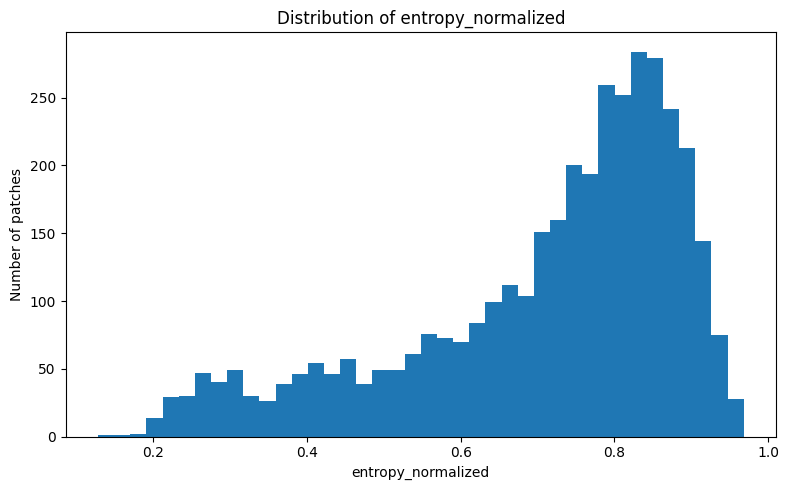

In [42]:
plt.figure(figsize=(8, 5))

plt.hist(df[entropy_col].dropna(), bins=40)

plt.title("Distribution of entropy_normalized")
plt.xlabel("entropy_normalized")
plt.ylabel("Number of patches")

plt.tight_layout()
plt.show()

## Entropy distribution interpretation

The entropy distribution now looks correct after regenerating entropy features for the current 8-city pilot.

The balanced dataset contains 3,808 patches, with 476 patches per city.

Most patches have medium-to-high entropy, especially between 0.70 and 0.90.

This means many patches contain mixed or irregular street directions.

There are fewer low-entropy patches, around 0.20 to 0.40.

These may represent more ordered or grid-like street patterns.

The target has enough variation to continue with regression-style analysis.

Next, we need to compare graph features directly against entropy.

## 13. Entropy distribution

This shows whether the target value has useful variation.

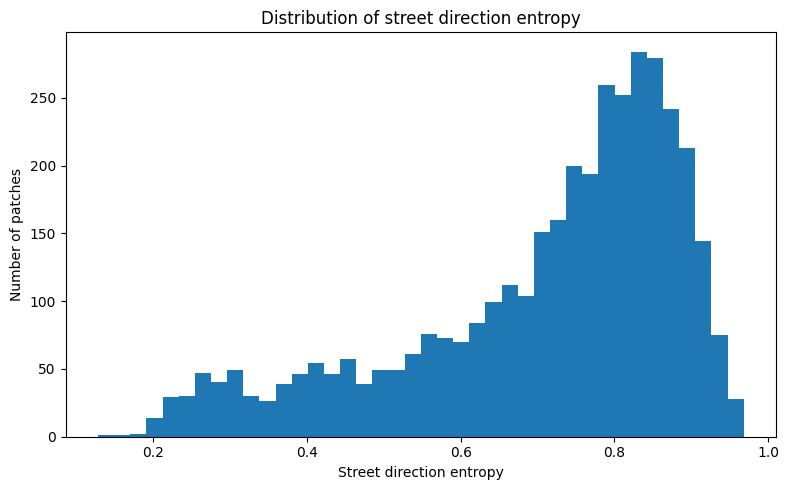

In [43]:
plt.figure(figsize=(8, 5))
plt.hist(df[entropy_col].dropna(), bins=40)
plt.title("Distribution of street direction entropy")
plt.xlabel(human_labels.get(entropy_col, entropy_col))
plt.ylabel("Number of patches")
plt.tight_layout()
plt.show()

## 14. Entropy by city

This checks whether entropy is city-dependent.

If cities separate strongly, the model may learn city identity instead of general street-network logic.

<Figure size 1000x500 with 0 Axes>

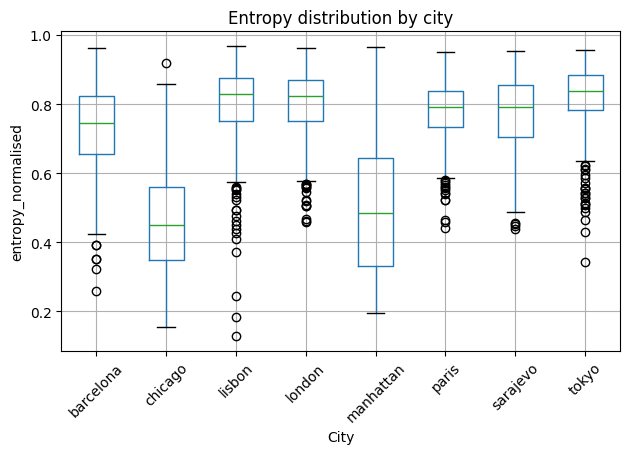

In [51]:
plt.figure(figsize=(10, 5))

df.boxplot(column=entropy_col, by="code", rot=45)

plt.title("Entropy distribution by city")
plt.suptitle("")
plt.xlabel("City")
plt.ylabel(entropy_col)

plt.tight_layout()
plt.show()

## Entropy by city interpretation

This plot shows that entropy varies strongly by city.

Chicago has the lowest entropy pattern, which fits its regular grid structure.

London, Lisbon, Sarajevo, and Tokyo show higher entropy values, which fits more irregular or complex street networks.

Barcelona and Paris sit in a medium-to-high range, showing mixed urban fabrics.

Manhattan has a wider spread than expected. This may come from the patch method capturing waterfronts, parks, edges, or non-grid areas.

This plot confirms that city identity matters.

The risk is that the model may learn city-specific patterns instead of general street-network logic.

Next, we need to compare entropy directly with graph features and color the plots by city.

## 15. Feature vs entropy viewer

Change `feature` to inspect one relationship at a time.

This is the most important visual test.

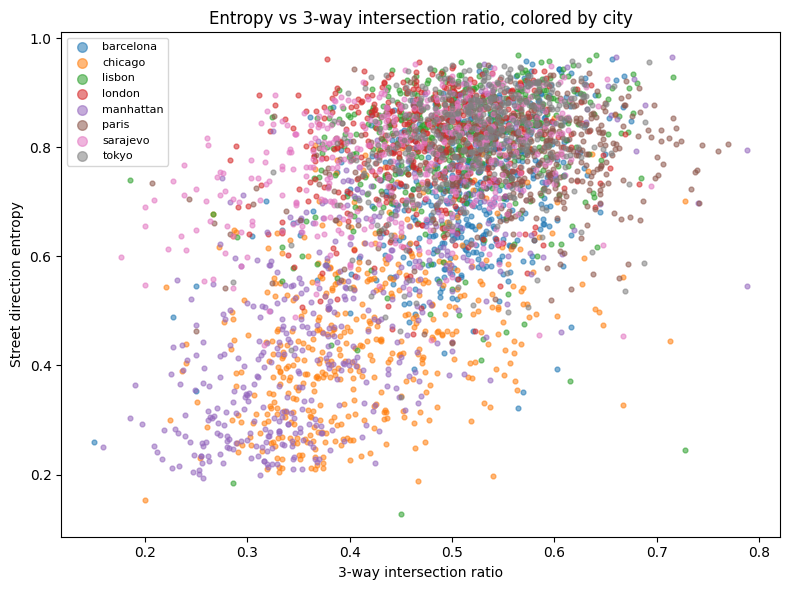

In [54]:
feature = "proportion_3way"

plt.figure(figsize=(8, 6))

for code, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=12,
        alpha=0.55,
        label=code
    )

plt.title("Entropy vs 3-way intersection ratio, colored by city")
plt.xlabel("3-way intersection ratio")
plt.ylabel("Street direction entropy")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs 3-way intersection ratio

This plot shows a weaker but still useful relationship between 3-way intersections and entropy.

Patches with more 3-way intersections often have higher street direction entropy.

This makes sense because 3-way intersections usually indicate branching or less rigid street-network logic.

The relationship is not as clear as proportion_4way.

This means proportion_3way is useful, but probably works best together with other graph features.

The city colors show that London, Lisbon, Sarajevo, and Tokyo mostly sit in the high-entropy zone.

Chicago and Manhattan include more low-entropy patches.

Barcelona and Paris are more mixed.

This supports the idea that intersection type helps explain entropy, but city identity still matters.

## 16. Feature vs entropy, colored by city

This shows whether the relationship is global or city-specific.

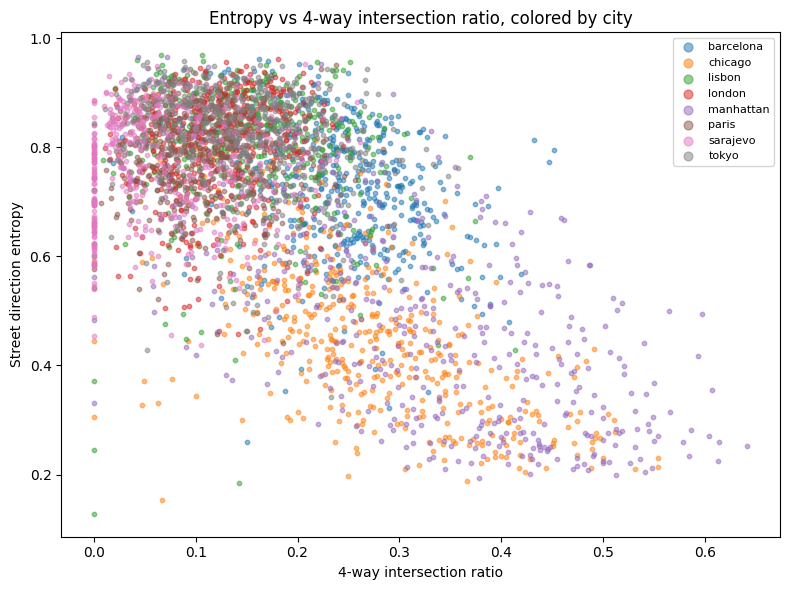

In [ ]:
feature = "proportion_4way"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title(f"Entropy vs {human_labels.get(feature, feature)}, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs 4-way intersection ratio

This plot shows a clear negative relationship between 4-way intersections and entropy.

Patches with more 4-way intersections tend to have lower street direction entropy.

This makes architectural sense because 4-way intersections usually appear in grid-like street networks.

Grid-like networks often have fewer dominant street directions.

This means proportion_4way is likely one of the strongest graph features for explaining entropy.

The city colors show that this relationship is partly linked to city identity.

Chicago and Manhattan occupy more of the high-4-way / low-entropy area.

London, Lisbon, Sarajevo, and Tokyo mostly occupy the low-4-way / high-entropy area.

Barcelona and Paris are more mixed.

This means the feature is useful, but we still need to check whether the model learns general street-network logic or simply city identity.

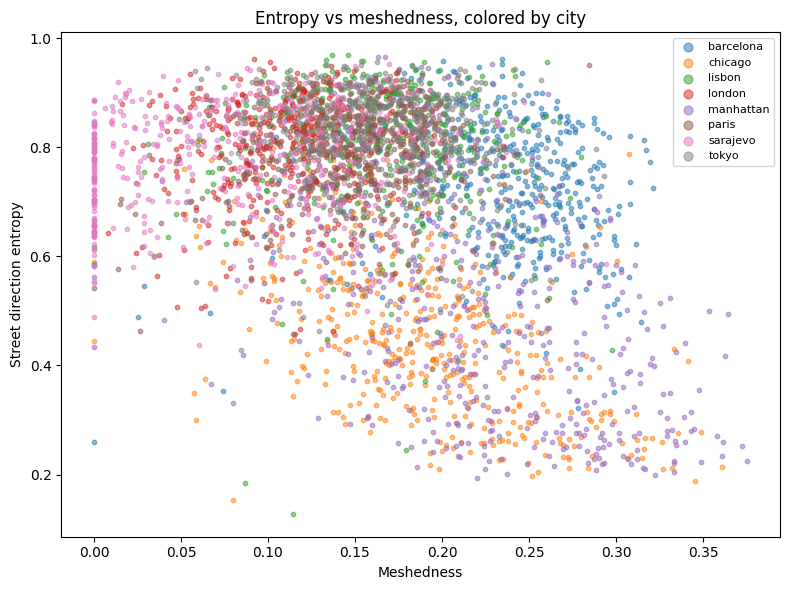

In [55]:
feature = "meshedness"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs meshedness, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs meshedness

This plot compares street direction entropy with meshedness.

Meshedness measures how much the street network forms loops.

The relationship is weaker than the relationship with proportion_4way.

Some low-entropy patches have medium-to-high meshedness, especially in grid-like cities.

However, many high-entropy patches also have medium meshedness.

This means a street network can be well connected but still directionally irregular.

Meshedness is useful for describing network connectivity, but it does not directly measure street-direction order.

For this reason, meshedness should be used as a supporting graph feature, not as the main entropy predictor.

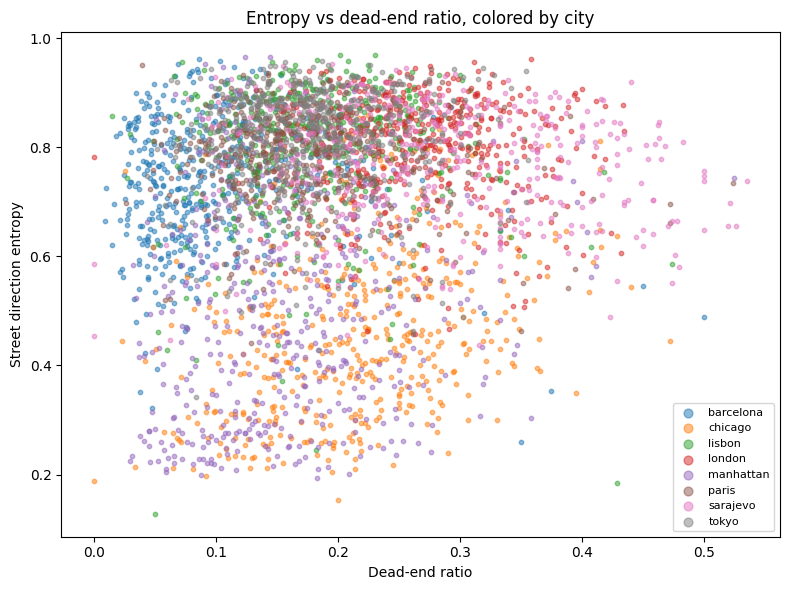

In [ ]:
feature = "dead_end_ratio"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs dead-end ratio, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs dead-end ratio

This plot compares street direction entropy with dead-end ratio.

The relationship is not very strong.

High-entropy patches appear across many dead-end ratio values.

This means dead-end ratio alone does not explain entropy well.

Dead-end ratio measures network fragmentation, while entropy measures street-direction order.

These are related only indirectly.

The feature is still useful because it can describe edge conditions, cul-de-sac patterns, terrain-constrained areas, or fragmented street networks.

For entropy prediction, dead_end_ratio should be treated as a supporting feature, not a primary predictor.

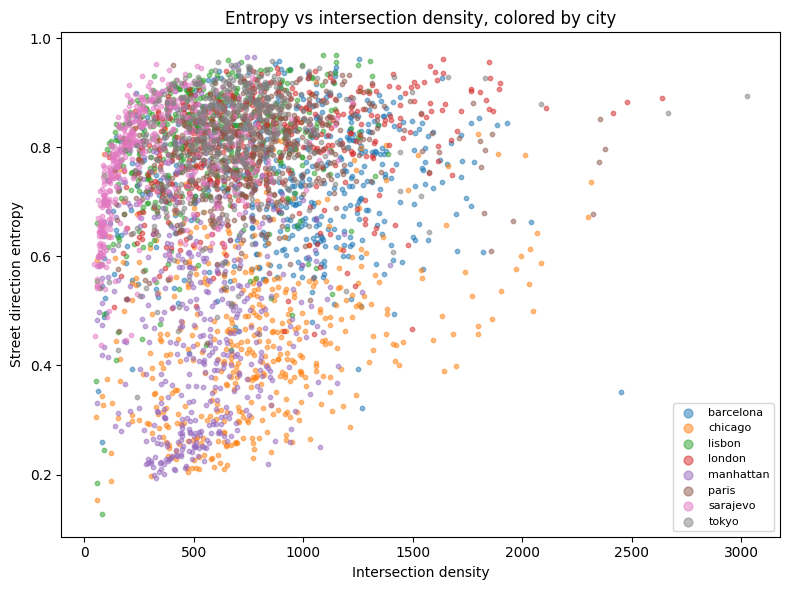

In [57]:
feature = "intersection_density"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs intersection density, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs intersection density

This plot compares street direction entropy with intersection density.

The relationship is not clearly linear.

High-entropy patches appear across low, medium, and high intersection densities.

This means intersection density alone does not explain entropy.

Intersection density measures how many decision points exist in a patch.

Entropy measures how ordered or irregular the street directions are.

A dense grid can have many intersections but low entropy.

A dense irregular network can also have many intersections but high entropy.

For this reason, intersection_density is useful for describing urban intensity, but it should be treated as a supporting feature for entropy prediction.

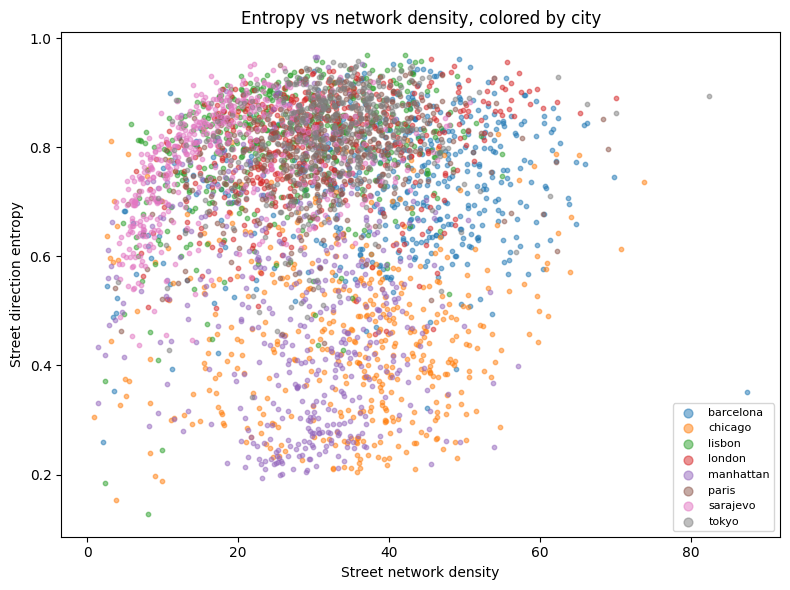

In [58]:
feature = "network_density"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs network density, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs network density

This plot compares street direction entropy with street network density.

The relationship is not clearly linear.

High-entropy patches appear across low, medium, and high network-density values.

This means network density alone does not explain entropy.

Network density measures how much street length exists inside a patch.

Entropy measures how ordered or irregular the street directions are.

A dense grid can have high network density but low entropy.

A dense irregular network can also have high network density but high entropy.

For this reason, network_density is useful for describing urban intensity, but it should be treated as a supporting feature for entropy prediction.

It may also overlap with intersection_density, so we should check correlation between these two features.

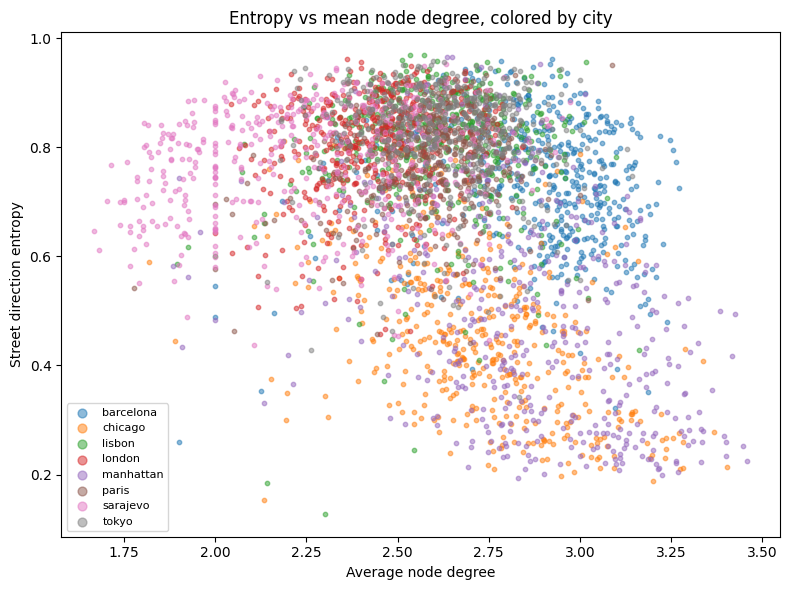

In [59]:
feature = "mean_node_degree"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs mean node degree, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs mean node degree

This plot compares street direction entropy with average node degree.

Mean node degree measures average street connectivity.

The plot shows that some lower-entropy patches have higher mean node degree, especially in Chicago and Manhattan.

This makes sense because grid-like networks usually have more connected intersections.

However, many high-entropy patches also have medium-to-high node degree.

This means a street network can be connected but still directionally irregular.

Mean node degree is useful for describing connectivity, but it is not enough alone to explain entropy.

It should be kept as a supporting feature.

We should compare it with proportion_4way, beta_index, and meshedness to check redundancy.

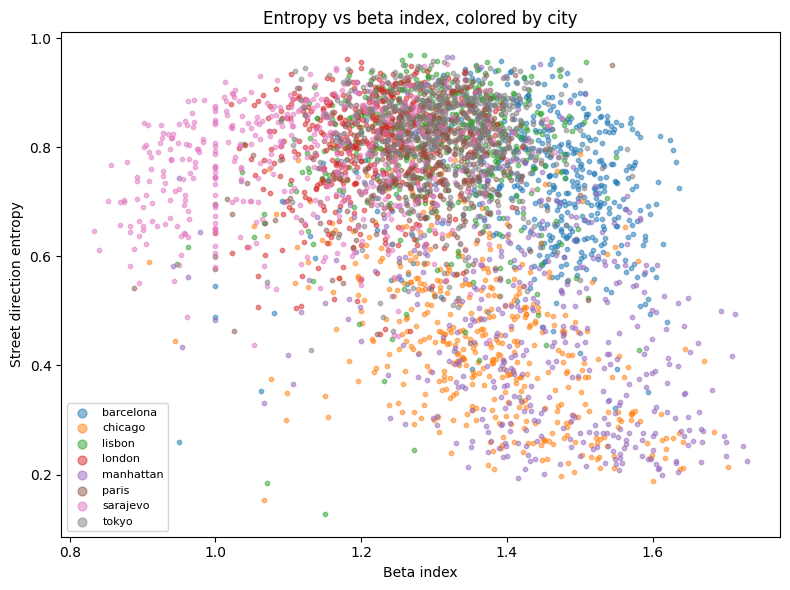

In [60]:
feature = "beta_index"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs beta index, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## What is beta_index?

beta_index compares the number of street segments to the number of street nodes.

It is a graph connectivity measure.

Higher beta_index means the street network has more connections and more route options.

Lower beta_index means the network is more tree-like or fragmented.

For this project, beta_index helps describe street-network connectivity, but it does not directly measure street-direction order.

The plot shows that beta_index may support entropy prediction, especially for grid-like cities such as Chicago and Manhattan.

However, it may overlap with mean_node_degree, so we should check the correlation matrix before deciding whether to keep both.

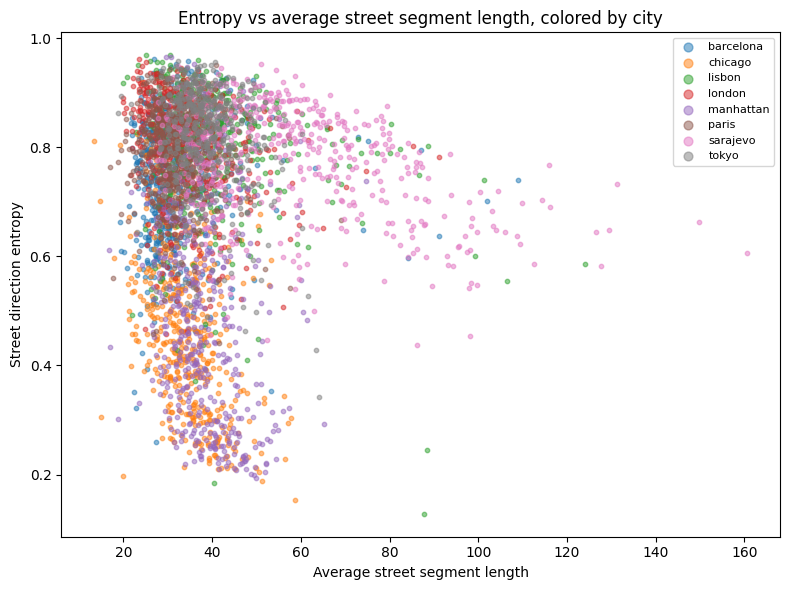

In [64]:
feature = "mean_edge_length"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs average street segment length, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs average street segment length

This plot compares street direction entropy with average street segment length.

The relationship is weak.

Most patches have average street segment lengths between 25 and 45 meters, but entropy varies widely inside that range.

This means average street segment length alone does not explain entropy well.

Mean edge length describes street segment scale, not street direction order.

Some long-segment outliers may represent parks, waterfronts, infrastructure corridors, sparse areas, or edge conditions.

For entropy prediction, mean_edge_length should be treated as a secondary feature.

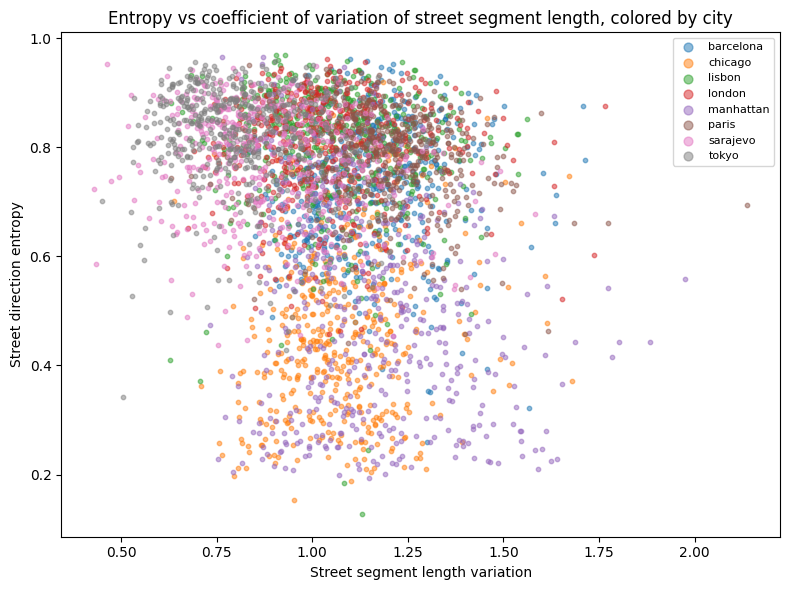

In [65]:
feature = "cv_edge_length"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title("Entropy vs coefficient of variation of street segment length, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

## Entropy vs street segment length variation

This plot compares street direction entropy with street segment length variation.

The relationship is weak to moderate.

cv_edge_length has a stronger relationship with entropy than mean_edge_length, but it is still not a primary predictor.

This feature measures how uneven street segment lengths are inside a patch.

High values may indicate mixed block sizes, edge conditions, infrastructure corridors, parks, or irregular urban grain.

The plot shows that cities overlap strongly, so this feature does not separate urban types clearly by itself.

For entropy prediction, cv_edge_length should be treated as a secondary feature.

# Phase 1 conclusion — Graph-feature EDA

The graph-feature EDA shows that intersection type is the strongest current explanation for street direction entropy.

The most important feature is proportion_4way.

It has the strongest negative relationship with entropy.

This means patches with more 4-way intersections tend to have lower entropy.

This fits the logic of grid-like street networks.

The second strongest feature is proportion_3way.

It has a positive relationship with entropy.

This means patches with more 3-way intersections tend to have higher entropy.

This fits branching or irregular street-network logic.

Connectivity features such as meshedness, mean_node_degree, and beta_index are also useful, but they may be partially redundant.

Density features such as intersection_density and network_density are weaker for entropy prediction.

They describe urban intensity, not street direction order.

Dead-end ratio and street segment length features are secondary.

They may help describe fragmentation, edge conditions, or irregular grain, but they are not primary entropy predictors.

Main finding:

Intersection type explains entropy better than general street density.

## 17. Correlation with entropy

This ranks graph features by linear relationship with entropy.

Important: weak correlation does not always mean useless. It only means the relationship is not strongly linear.

In [61]:
corr_with_entropy = (
    df[graph_features + [entropy_col]]
    .corr(numeric_only=True)[entropy_col]
    .drop(entropy_col)
    .sort_values(ascending=False)
)

corr_with_entropy

proportion_3way         0.544645
intersection_density    0.112974
dead_end_ratio          0.087321
network_density         0.016612
mean_edge_length       -0.041005
cv_edge_length         -0.210071
beta_index             -0.337440
mean_node_degree       -0.337443
meshedness             -0.372237
proportion_4way        -0.622678
Name: entropy_normalised, dtype: float64

## Correlation with entropy

The strongest graph feature is proportion_4way.

It has a negative correlation with entropy.

This means patches with more 4-way intersections tend to have lower street direction entropy.

This supports the idea that grid-like networks are more directionally ordered.

The strongest positive feature is proportion_3way.

This means patches with more 3-way intersections tend to have higher entropy.

This supports the idea that branching or irregular street networks have more varied street directions.

Meshedness, mean_node_degree, and beta_index also have negative correlations with entropy.

These features describe network connectivity.

They may support the same pattern as proportion_4way, but they may also be redundant.

Intersection density and network density are weakly related to entropy.

This means the amount of street network does not explain direction order by itself.

Dead-end ratio is also weak.

Main conclusion:

Intersection type appears more important than network density for explaining entropy.

## 18. Correlation matrix

This helps identify redundant features.

Look especially for:

- network density vs intersection density
- beta index vs mean node degree
- proportion 3-way vs proportion 4-way
- graph features vs entropy

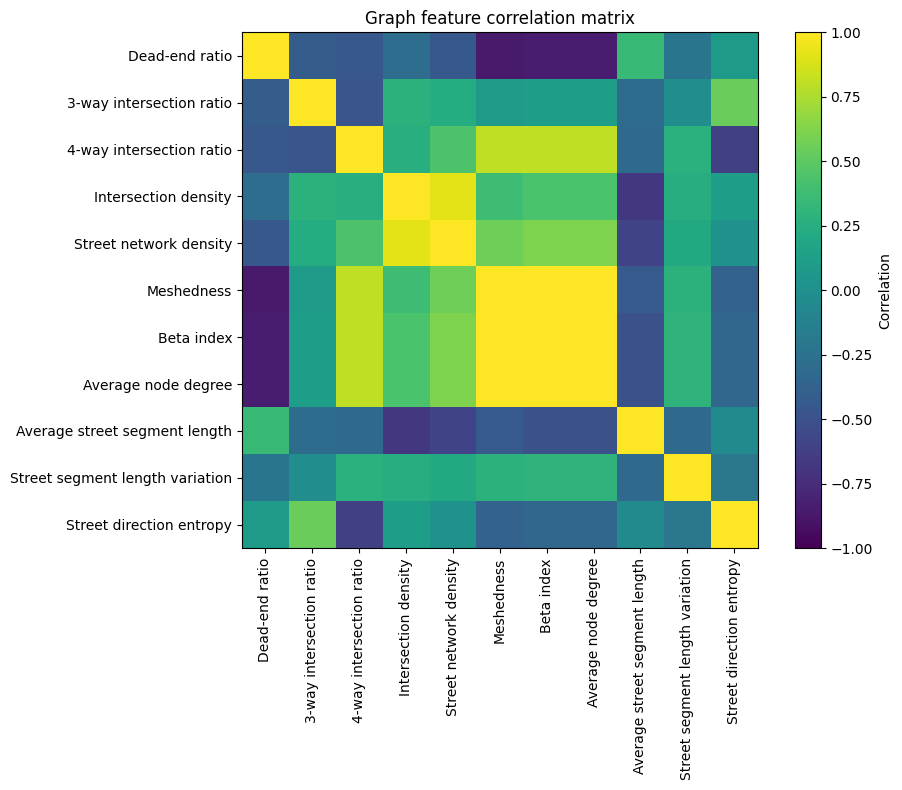

In [62]:
corr = df[graph_features + [entropy_col]].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), [human_labels.get(c, c) for c in corr.columns], rotation=90)
plt.yticks(range(len(corr.index)), [human_labels.get(c, c) for c in corr.index])
plt.colorbar(label="Correlation")
plt.title("Graph feature correlation matrix")
plt.tight_layout()
plt.show()

## Correlation matrix interpretation

The correlation matrix shows both feature-to-entropy relationships and feature redundancy.

The strongest relationship with street direction entropy is proportion_4way.

It is negatively correlated with entropy.

This means patches with more 4-way intersections tend to have lower entropy.

This supports the idea that grid-like networks are more directionally ordered.

proportion_3way is positively correlated with entropy.

This suggests that branching or irregular street networks tend to have more varied street directions.

The matrix also shows redundancy between meshedness, beta_index, mean_node_degree, and proportion_4way.

These features all describe network connectivity or grid strength.

Intersection_density and network_density also appear related.

This means some features may repeat similar information.

Main conclusion:

Intersection type appears more useful than general street density for explaining entropy.

Next decision:

We need to decide whether to keep all graph features or reduce redundant ones before model training.

## Phase 2 — Graph feature selection

# Phase 2 — Graph feature selection

This phase decides which graph features should be kept, reviewed, or possibly removed before model training.

The decision is based on:

- feature meaning
- entropy relationship
- correlation strength
- redundancy with other features
- visual clarity in scatter plots

We do not remove features yet.

We first create a feature decision table.

## Graph feature decision table

| Feature | Decision | Reason |
|---|---|---|
| proportion_4way | Keep | Strongest negative relationship with entropy |
| proportion_3way | Keep | Strongest positive relationship with entropy |
| meshedness | Keep | Useful connectivity feature, moderate relationship |
| mean_node_degree | Review | Useful, but may overlap with beta_index |
| beta_index | Review | Similar to mean_node_degree |
| intersection_density | Review | Weak entropy relation, describes urban intensity |
| network_density | Review | Very weak entropy relation, may overlap with intersection_density |
| dead_end_ratio | Keep as support | Weak entropy relation, but meaningful for fragmentation |
| mean_edge_length | Review | Very weak entropy relation |
| cv_edge_length | Keep as support | Secondary feature for street grain variation |

## Phase 2 initial decision

The graph-feature EDA suggests that intersection type should be central to the model.

The two strongest features are proportion_4way and proportion_3way.

These features directly describe whether a street network is more grid-like or more branching.

Connectivity features such as meshedness, mean_node_degree, and beta_index are useful, but they may overlap.

Density features are weaker for entropy prediction.

This means the next model should compare three feature sets:

1. all graph features
2. selected graph features
3. minimal interpretable graph features

In [1]:
all_graph_features = [
    "dead_end_ratio",
    "proportion_3way",
    "proportion_4way",
    "intersection_density",
    "network_density",
    "meshedness",
    "beta_index",
    "mean_node_degree",
    "mean_edge_length",
    "cv_edge_length",
]

selected_graph_features = [
    "proportion_4way",
    "proportion_3way",
    "meshedness",
    "intersection_density",
    "dead_end_ratio",
    "cv_edge_length",
]

minimal_graph_features = [
    "proportion_4way",
    "proportion_3way",
    "meshedness",
]

print("All graph features:", len(all_graph_features))
print("Selected graph features:", len(selected_graph_features))
print("Minimal graph features:", len(minimal_graph_features))

All graph features: 10
Selected graph features: 6
Minimal graph features: 3


## Feature set logic

We define three graph-feature sets for later model testing.

The all-feature set keeps every graph feature.

The selected-feature set keeps the strongest and most interpretable features.

The minimal-feature set keeps only the clearest entropy-related features.

This prepares the first ablation study.

An ablation study means comparing model performance after removing or changing feature groups.

## Phase 2 conclusion — Feature selection

We created three graph-feature sets for later model testing.

The all-feature set keeps every graph feature and acts as the baseline.

The selected-feature set keeps the strongest and most interpretable features while reducing redundancy.

The minimal-feature set keeps only proportion_4way, proportion_3way, and meshedness.

These three sets will allow us to compare whether more features improve prediction or whether fewer, clearer features are enough.

This prepares the first ablation study.

## 18. Correlation matrix

This helps identify redundant features.

Look especially for:

- network density vs intersection density
- beta index vs mean node degree
- proportion 3-way vs proportion 4-way
- graph features vs entropy

## 19. Save selected figure manually

Only run this cell when the current plot is useful.

Change `feature` and `filename` before saving.

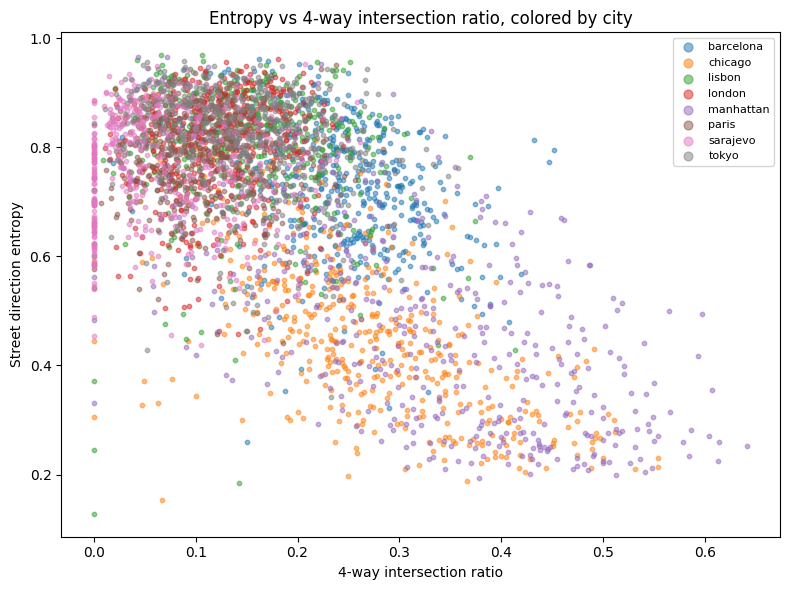

Saved: d:\GitHub\Urban-morphology-classification-\data\processed_global\selected_graph_eda\entropy_vs_proportion_4way_by_city.png


In [49]:
feature = "proportion_4way"
filename = f"entropy_vs_{feature}_by_city.png"

plt.figure(figsize=(8, 6))

for code_name, group in df.groupby("code"):
    plt.scatter(
        group[feature],
        group[entropy_col],
        s=10,
        alpha=0.5,
        label=code_name,
    )

plt.title(f"Entropy vs {human_labels.get(feature, feature)}, colored by city")
plt.xlabel(human_labels.get(feature, feature))
plt.ylabel(human_labels.get(entropy_col, entropy_col))
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()

save_path = OUTPUT_DIR / filename
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

## 20. Notes and decisions

Use this section after looking at the plots.

Write short notes:

- Which features look useful?
- Which features look redundant?
- Which features have outliers?
- Which plots should be saved for the support session?
- Which question should we ask next?

In [50]:
notes = """
Initial notes:

- Histograms show graph features have usable variation.
- Next decision: check which graph features relate to entropy.
- Watch for city-specific clustering.
- Watch for redundant density features.
"""

print(notes)


Initial notes:

- Histograms show graph features have usable variation.
- Next decision: check which graph features relate to entropy.
- Watch for city-specific clustering.
- Watch for redundant density features.

